In [133]:
import pandas as pd
import numpy as np

In [135]:
# load data
df = pd.read_csv("nhanes_cardiometabolic_subset_dataset.csv")

In [137]:
# define target variable
target = "HYPERTENSION_YN"

In [139]:
# variables to remove
drop_cols = [
    "SEQN",
    "BPXSY1","BPXSY2","BPXSY3","BPXSY4",
    "BPXDI1","BPXDI2","BPXDI3","BPXDI4",
    "BPXPULS",
    "BP_CATEGORY","HTN_STAGE",
    "BPQ020","BPQ030",
    "PAD615","DIQ070","BPQ050A","DBQ010",
    "ACR_MG_PER_G","URXUCR"
]

In [141]:
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

print("Dataset shape after initial cleaning:", df.shape)

Dataset shape after initial cleaning: (10175, 44)


In [143]:
# separate predictors and target
X = df.drop(columns=[target])
y = df[target]

In [145]:
# missing summary
missing = X.isnull().sum()
missing_pct = (X.isnull().mean()*100).round(2)

missing_summary = pd.DataFrame({
    "Missing_Count": missing,
    "Missing_Percent": missing_pct
}).sort_values("Missing_Percent", ascending=False)

print("Top missing variables:\n")
print(missing_summary.head(15))

print("\nVariables with any missing data:", (missing>0).sum())

Top missing variables:

              Missing_Count  Missing_Percent
SMQ040                 7596            74.65
LBXIN                  7082            69.60
LBDLDL                 7070            69.48
RATIO_TG_HDL           7029            69.08
LBXTR                  7029            69.08
ALQ120U                6582            64.69
ALQ120Q                5696            55.98
DMDEDUC2               4406            43.30
DMDMARTL               4406            43.30
SMQ020                 4062            39.92
SLQ060                 3711            36.47
SLQ050                 3711            36.47
DBQ700                 3711            36.47
BPQ080                 3711            36.47
HSD010                 3708            36.44

Variables with any missing data: 40


In [147]:
drop_missing = [
    "SMQ040",
    "LBXIN",
    "LBDLDL",
    "RATIO_TG_HDL",
    "LBXTR",
    "ALQ120U",
    "ALQ120Q"
]

df = df.drop(columns=[c for c in drop_missing if c in df.columns])

print("Dataset shape after removing high-missing variables:", df.shape)

Dataset shape after removing high-missing variables: (10175, 37)


In [149]:
# check target variable

print("Missing values in target:")
print(df[target].isnull().sum())

print("\nTarget value counts:")
print(df[target].value_counts())

print("\nTarget proportions:")
print(df[target].value_counts(normalize=True).round(3))

Missing values in target:
0

Target value counts:
HYPERTENSION_YN
0    7115
1    3060
Name: count, dtype: int64

Target proportions:
HYPERTENSION_YN
0    0.699
1    0.301
Name: proportion, dtype: float64


In [151]:
# define predictors and target
X = df.drop(columns=[target])
y = df[target]

In [153]:
# detect numeric vs categorical variables
numeric_features = X.select_dtypes(include=["int64","float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object","category"]).columns.tolist()

print("Total predictors:", X.shape[1])
print("Numeric predictors:", len(numeric_features))
print("Categorical predictors:", len(categorical_features))

print("\nNumeric variables:")
print(numeric_features)

print("\nCategorical variables:")
print(categorical_features)

Total predictors: 36
Numeric predictors: 36
Categorical predictors: 0

Numeric variables:
['BPXSY_AVG', 'BPXDI_AVG', 'RIDAGEYR', 'RIAGENDR', 'RIDRETH1', 'DMDEDUC2', 'INDFMPIR', 'DMDMARTL', 'BMXWT', 'BMXHT', 'BMXBMI', 'BMXWAIST', 'BMXARML', 'BMXARMC', 'BMXLEG', 'LBXGH', 'DIQ010', 'DIQ050', 'LBXTC', 'LBDHDD', 'RATIO_TC_HDL', 'LBXSCR', 'URXUMA', 'eGFR_CKD_EPI_2021', 'LBXSAL', 'LBXWBCSI', 'LBXPLTSI', 'SMQ020', 'PAQ605', 'PAQ620', 'PAQ650', 'DBQ700', 'SLQ050', 'SLQ060', 'HSD010', 'BPQ080']

Categorical variables:
[]


In [155]:
# convert categorical variables

categorical_vars = [
    "RIAGENDR",
    "RIDRETH1",
    "DMDEDUC2",
    "DMDMARTL",
    "DIQ010",
    "DIQ050",
    "SMQ020",
    "PAQ605",
    "PAQ620",
    "PAQ650",
    "DBQ700",
    "SLQ050",
    "SLQ060",
    "HSD010",
    "BPQ080"
]

for col in categorical_vars:
    if col in df.columns:
        df[col] = df[col].astype("category")

print("Categorical conversion complete.")

Categorical conversion complete.


In [157]:
X = df.drop(columns=[target])
y = df[target]

numeric_features = X.select_dtypes(include=["int64","float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["category","object"]).columns.tolist()

print("Numeric predictors:", len(numeric_features))
print("Categorical predictors:", len(categorical_features))

Numeric predictors: 21
Categorical predictors: 15


In [159]:
from sklearn.model_selection import train_test_split

In [161]:
# train model

X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [163]:
print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain class distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTest class distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training shape: (8140, 36)
Test shape: (2035, 36)

Train class distribution:
HYPERTENSION_YN
0    0.699
1    0.301
Name: proportion, dtype: float64

Test class distribution:
HYPERTENSION_YN
0    0.699
1    0.301
Name: proportion, dtype: float64


In [165]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

In [167]:
# numeric pipeline
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# categorical pipeline
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

# combine preprocessing
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

print("Preprocessing pipeline created.")

Preprocessing pipeline created.


In [169]:
# logistic regression (baseline)

from sklearn.linear_model import LogisticRegression

model = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", LogisticRegression(max_iter=2000))
])

print("Model pipeline ready.")

Model pipeline ready.


In [171]:
model.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


In [95]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# predictions
y_pred = model.predict(X_test)

# metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", round(accuracy,3))
print("Precision:", round(precision,3))
print("Recall:", round(recall,3))
print("F1 Score:", round(f1,3))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.892
Precision: 0.817
Recall: 0.825
F1 Score: 0.821

Confusion Matrix:
[[1310  113]
 [ 107  505]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.92      0.92      1423
           1       0.82      0.83      0.82       612

    accuracy                           0.89      2035
   macro avg       0.87      0.87      0.87      2035
weighted avg       0.89      0.89      0.89      2035



C:\Users\ellie\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:241: UserWarning: Found unknown categories in columns [7, 8, 10] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [97]:
from sklearn.metrics import roc_curve, roc_auc_score

# predicted probabilities
y_prob = model.predict_proba(X_test)[:,1]

# ROC metrics
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

print("ROC AUC:", round(auc_score,3))

ROC AUC: 0.959


C:\Users\ellie\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:241: UserWarning: Found unknown categories in columns [7, 8, 10] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


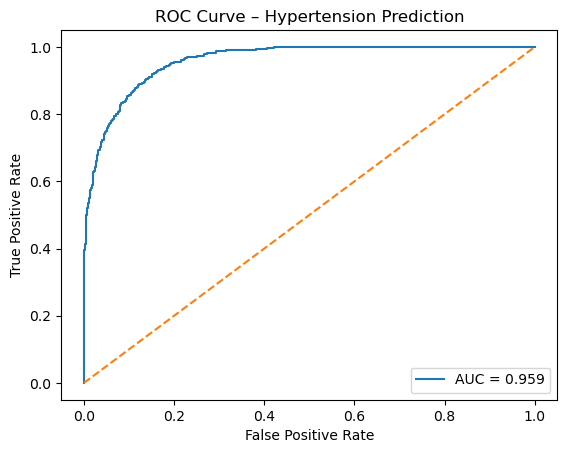

In [99]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Hypertension Prediction")
plt.legend()
plt.show()

In [101]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="roc_auc"
)

print("Cross-validation AUC scores:", cv_scores)
print("Mean AUC:", round(cv_scores.mean(),3))
print("Std Dev:", round(cv_scores.std(),3))

C:\Users\ellie\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:241: UserWarning: Found unknown categories in columns [4, 5, 7, 8] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\ellie\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:241: UserWarning: Found unknown categories in columns [10] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\ellie\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:241: UserWarning: Found unknown categories in columns [3, 9, 13] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\ellie\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:241: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Cross-validation AUC scores: [0.96027219 0.95617287 0.95785393 0.95356515 0.96293273]
Mean AUC: 0.958
Std Dev: 0.003


In [103]:
# get feature names after preprocessing
feature_names = model.named_steps["preprocessing"].get_feature_names_out()

# get coefficients
coefficients = model.named_steps["classifier"].coef_[0]

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Abs_Coefficient": abs(coefficients)
})

coef_df = coef_df.sort_values("Abs_Coefficient", ascending=False)

coef_df.head(10)

,Feature,Coefficient,Abs_Coefficient
0,num__BPXSY_AVG,1.867796,1.867796
2,num__RIDAGEYR,1.576122,1.576122
60,cat__SLQ060_9.0,0.897502,0.897502
15,num__LBXSCR,0.874009,0.874009
50,cat__PAQ620_9.0,-0.707854,0.707854
63,cat__HSD010_4.0,0.694953,0.694953
64,cat__HSD010_5.0,0.620833,0.620833
21,cat__RIAGENDR_2.0,0.603809,0.603809
39,cat__DIQ010_2.0,-0.589366,0.589366
62,cat__HSD010_3.0,0.569106,0.569106


In [105]:
coef_df["Feature"] = coef_df["Feature"].str.replace("num__", "", regex=False)
coef_df["Feature"] = coef_df["Feature"].str.replace("cat__", "", regex=False)

coef_df.head(5)

,Feature,Coefficient,Abs_Coefficient
0,BPXSY_AVG,1.867796,1.867796
2,RIDAGEYR,1.576122,1.576122
60,SLQ060_9.0,0.897502,0.897502
15,LBXSCR,0.874009,0.874009
50,PAQ620_9.0,-0.707854,0.707854


In [107]:
top_positive = coef_df.sort_values("Coefficient", ascending=False).head(10)
top_negative = coef_df.sort_values("Coefficient").head(10)

print("Top variables associated with HIGHER hypertension risk")
display(top_positive)

print("\nTop variables associated with LOWER hypertension risk")
display(top_negative)

Top variables associated with HIGHER hypertension risk


,Feature,Coefficient,Abs_Coefficient
0,BPXSY_AVG,1.867796,1.867796
2,RIDAGEYR,1.576122,1.576122
60,SLQ060_9.0,0.897502,0.897502
15,LBXSCR,0.874009,0.874009
63,HSD010_4.0,0.694953,0.694953
64,HSD010_5.0,0.620833,0.620833
21,RIAGENDR_2.0,0.603809,0.603809
62,HSD010_3.0,0.569106,0.569106
8,BMXARML,0.562331,0.562331
24,RIDRETH1_4.0,0.544346,0.544346



Top variables associated with LOWER hypertension risk


,Feature,Coefficient,Abs_Coefficient
50,PAQ620_9.0,-0.707854,0.707854
39,DIQ010_2.0,-0.589366,0.589366
66,BPQ080_2.0,-0.568145,0.568145
47,SMQ020_9.0,-0.529299,0.529299
57,SLQ050_2.0,-0.424373,0.424373
67,BPQ080_9.0,-0.335786,0.335786
65,HSD010_9.0,-0.189177,0.189177
59,SLQ060_2.0,-0.146557,0.146557
54,DBQ700_3.0,-0.144690,0.144690
48,PAQ605_2.0,-0.134775,0.134775


### random forest model:

In [173]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

In [175]:
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42
    ))
])

In [177]:
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [178]:
rf_pred = rf_model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, rf_pred),3))
print("Precision:", round(precision_score(y_test, rf_pred),3))
print("Recall:", round(recall_score(y_test, rf_pred),3))
print("F1 Score:", round(f1_score(y_test, rf_pred),3))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

C:\Users\ellie\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:241: UserWarning: Found unknown categories in columns [7, 8, 10] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Accuracy: 0.92
Precision: 0.884
Recall: 0.846
F1 Score: 0.865

Confusion Matrix:
[[1355   68]
 [  94  518]]


In [181]:
auc_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring="roc_auc"
)

print("Cross-validation AUC scores:", auc_scores)
print("Mean AUC:", auc_scores.mean().round(3))
print("Std Dev:", auc_scores.std().round(3))

C:\Users\ellie\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:241: UserWarning: Found unknown categories in columns [4, 5, 7, 8] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\ellie\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:241: UserWarning: Found unknown categories in columns [10] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\ellie\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:241: UserWarning: Found unknown categories in columns [3, 9, 13] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\ellie\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:241: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Cross-validation AUC scores: [0.97398711 0.97227045 0.97240365 0.9726155  0.97505615]
Mean AUC: 0.973
Std Dev: 0.001


In [121]:
# get trained random forest model
rf_classifier = rf_model.named_steps["model"]

# get feature names after preprocessing
feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()

In [123]:
# create importance series
importance = pd.Series(rf_classifier.feature_importances_, index=feature_names)

In [125]:
# clean names a little
importance.index = importance.index.str.replace("num__", "", regex=False)
importance.index = importance.index.str.replace("cat__", "", regex=False)

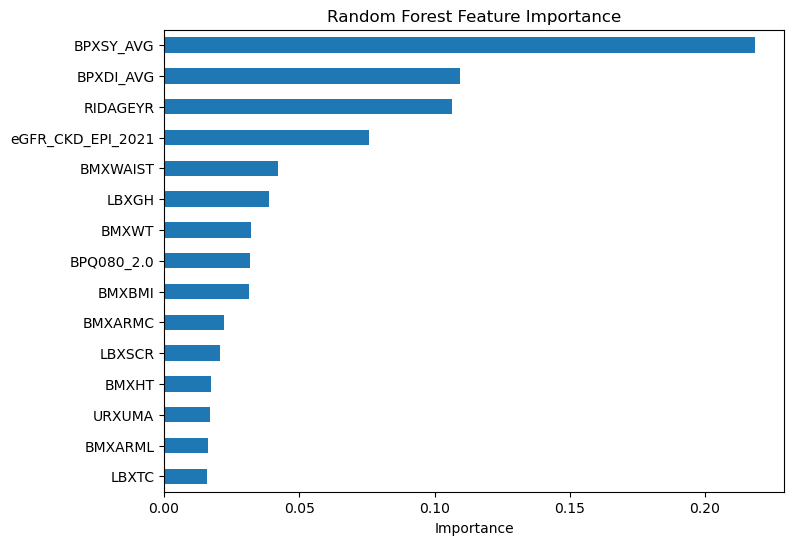

In [127]:
# top 15 features
top_features = importance.sort_values(ascending=False).head(15)

plt.figure(figsize=(8,6))
top_features.sort_values().plot(kind="barh")
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.show()

#### references:

##### https://www.datacamp.com/tutorial/random-forests-classifier-python
##### https://data36.com/random-forest-in-python/
##### https://stackoverflow.com/questions/25009284/how-to-plot-roc-curve-in-python